In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Cargar el dataset y mostrar sus columnas

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/PLN/subtask1/train.csv'

try:
    # Asumiendo que es un archivo CSV, puedes ajustarlo para Excel, JSON, etc.
    df = pd.read_csv(file_path)
    print(f'Dataset cargado exitosamente desde: {file_path}')

    # Mostrar las primeras 5 filas del DataFrame
    print('\nPrimeras 5 filas del dataset:')
    display(df.head())

    # Mostrar los nombres de las columnas
    print('\nNombres de las columnas:')
    for col in df.columns:
        print(f'- {col}')

    # También puedes ver un resumen de la información del DataFrame, incluyendo las columnas y sus tipos de datos
    print('\nInformación del DataFrame:')
    df.info()

except FileNotFoundError:
    print(f'Error: El archivo no fue encontrado en la ruta: {file_path}')
    print('Por favor, verifica que la ruta sea correcta y que el archivo exista en tu Google Drive.')
except Exception as e:
    print(f'Ocurrió un error al cargar el dataset: {e}')

Dataset cargado exitosamente desde: /content/drive/MyDrive/PLN/subtask1/train.csv

Primeras 5 filas del dataset:


,ID,TEXT,CLASS
0,1,MENCIONA QUE REALIZO EL TRAMITE DE DIVORCIO Y ...,0
1,2,"LA USUARIA ESPOSA DEL AGRESOR, DICE QUE LLEVAN...",0
2,3,USUARIA MENCIONA QUE LLEGO SU EX PAREJA A VER ...,0
3,4,USUARIA ACUDE PARA TRAMITE DE ALIMENTOS.,0
4,5,LA USUARIA EXPAREJA DEL AGRESOR CON UNA HIJA E...,0



Nombres de las columnas:
- ID
- TEXT
- CLASS

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13630 entries, 0 to 13629
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      13630 non-null  int64 
 1   TEXT    13630 non-null  object
 2   CLASS   13630 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 319.6+ KB


In [ ]:
# Calcular el número de duplicados basados en 'TEXT' y 'CLASS'
duplicates_functional_count = df.duplicated(subset=['TEXT', 'CLASS']).sum()

print(f'Número de filas funcionalmente duplicadas (mismo TEXT y CLASS): {duplicates_functional_count}')

# Si quieres ver algunas de estas filas duplicadas (primeras 5 ocurrencias)
# duplicated_rows = df[df.duplicated(subset=['TEXT', 'CLASS'], keep=False)].sort_values(by=['TEXT', 'CLASS'])
# display(duplicated_rows.head())

Número de filas funcionalmente duplicadas (mismo TEXT y CLASS): 127


### 2. Eliminar Duplicados Funcionales
Eliminamos las filas que tienen el mismo `TEXT` y `CLASS`, ya que se consideran duplicados funcionales para nuestro análisis.

In [ ]:
initial_rows = len(df)
df_cleaned = df.drop_duplicates(subset=['TEXT', 'CLASS']).reset_index(drop=True)
final_rows = len(df_cleaned)

print(f'Filas iniciales: {initial_rows}')
print(f'Filas después de eliminar duplicados funcionales: {final_rows}')
print(f'Número de filas eliminadas: {initial_rows - final_rows}')

df = df_cleaned.copy()
print('\nDataFrame actualizado (primeras 5 filas después de la limpieza):')
display(df.head())

print('\nInformación del DataFrame después de eliminar duplicados:')
df.info()

Filas iniciales: 13630
Filas después de eliminar duplicados funcionales: 13503
Número de filas eliminadas: 127

DataFrame actualizado (primeras 5 filas después de la limpieza):


,ID,TEXT,CLASS
0,1,MENCIONA QUE REALIZO EL TRAMITE DE DIVORCIO Y ...,0
1,2,"LA USUARIA ESPOSA DEL AGRESOR, DICE QUE LLEVAN...",0
2,3,USUARIA MENCIONA QUE LLEGO SU EX PAREJA A VER ...,0
3,4,USUARIA ACUDE PARA TRAMITE DE ALIMENTOS.,0
4,5,LA USUARIA EXPAREJA DEL AGRESOR CON UNA HIJA E...,0



Información del DataFrame después de eliminar duplicados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13503 entries, 0 to 13502
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      13503 non-null  int64 
 1   TEXT    13503 non-null  object
 2   CLASS   13503 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 316.6+ KB


### 3. Revisión del Balance de Categorías en la Columna 'CLASS'
Vamos a examinar la distribución de las diferentes categorías en la columna `CLASS` para entender si nuestro dataset está balanceado o desbalanceado.

Balance de categorías en la columna CLASS:
CLASS
0    2839
1    4733
2    5315
3     616
Name: count, dtype: int64


/tmp/ipykernel_2932/3889032063.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


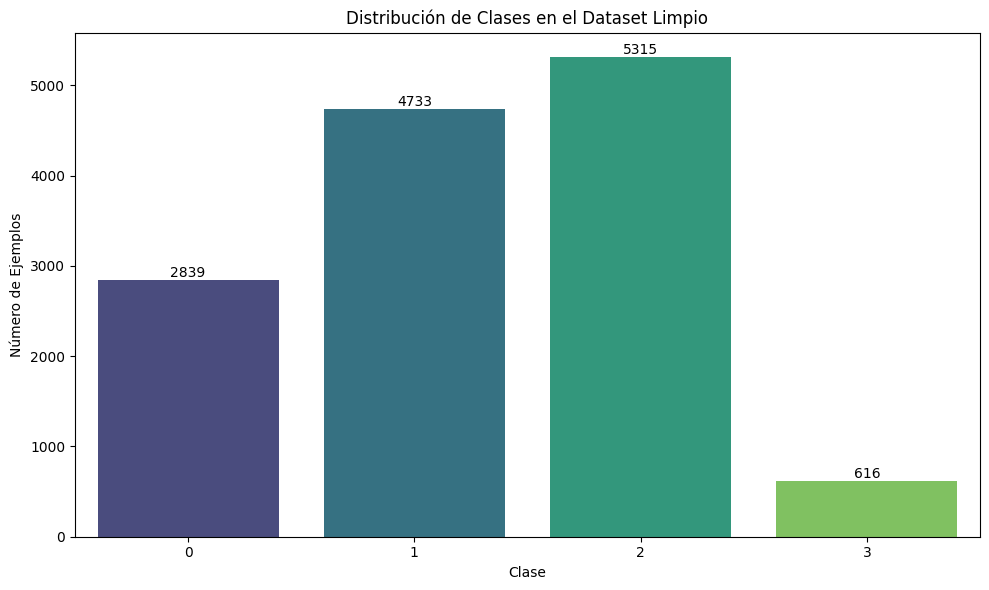

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el conteo de cada categoría en la columna 'CLASS'
class_counts = df['CLASS'].value_counts().sort_index()

print('Balance de categorías en la columna CLASS:')
print(class_counts)

# Visualizar la distribución de las categorías
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribución de Clases en el Dataset Limpio')
plt.xlabel('Clase')
plt.ylabel('Número de Ejemplos')
plt.xticks(rotation=0) # Asegura que las etiquetas de clase estén legibles

# Añadir el conteo exacto encima de cada barra
for index, value in enumerate(class_counts.values):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 4. Cargar el Dataset de Desarrollo
Ahora, cargaremos el dataset de desarrollo y realizaremos los mismos pasos de inspección inicial para entender su estructura.

In [ ]:
file_path_dev = '/content/drive/MyDrive/PLN/subtask1/devel.csv'

try:
    df_dev = pd.read_csv(file_path_dev)
    print(f'Dataset de desarrollo cargado exitosamente desde: {file_path_dev}')

    print('\nPrimeras 5 filas del dataset de desarrollo:')
    display(df_dev.head())

    print('\nNombres de las columnas del dataset de desarrollo:')
    for col_dev in df_dev.columns:
        print(f'- {col_dev}')

    print('\nInformación del DataFrame de desarrollo:')
    df_dev.info()

except FileNotFoundError:
    print(f'Error: El archivo de desarrollo no fue encontrado en la ruta: {file_path_dev}')
    print('Por favor, verifica que la ruta sea correcta y que el archivo exista en tu Google Drive.')
except Exception as e:
    print(f'Ocurrió un error al cargar el dataset de desarrollo: {e}')

Dataset de desarrollo cargado exitosamente desde: /content/drive/MyDrive/PLN/subtask1/devel.csv

Primeras 5 filas del dataset de desarrollo:


,ID,TEXT,CLASS
0,3877,USUARIA REFIERE QUE AGRESOR ES SU EX PAREJA Y ...,0
1,3878,USUARIA MANIFIESTA QUE ACUDE TODA VEZ QUE SU E...,0
2,3879,USUARIA MENCIONA QUE ELLA QUIERE REALIZAR TRAM...,0
3,3880,USUARIA MENCIONA QUE TIENE TRES MESES SEPARADA...,0
4,3881,USUARIA REFIERE QUE SU HIJA ES USUARIA DE LA I...,0



Nombres de las columnas del dataset de desarrollo:
- ID
- TEXT
- CLASS

Información del DataFrame de desarrollo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3405 entries, 0 to 3404
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      3405 non-null   object
 1   TEXT    3405 non-null   object
 2   CLASS   3405 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 79.9+ KB


### 7. Revisión del Balance de Categorías en la Columna 'CLASS' del Dataset de Desarrollo
Finalmente, vamos a revisar el balance de categorías en la columna `CLASS` para el dataset de desarrollo.

Balance de categorías en la columna CLASS del dataset de desarrollo:
CLASS
0     739
1    1183
2    1329
3     154
Name: count, dtype: int64


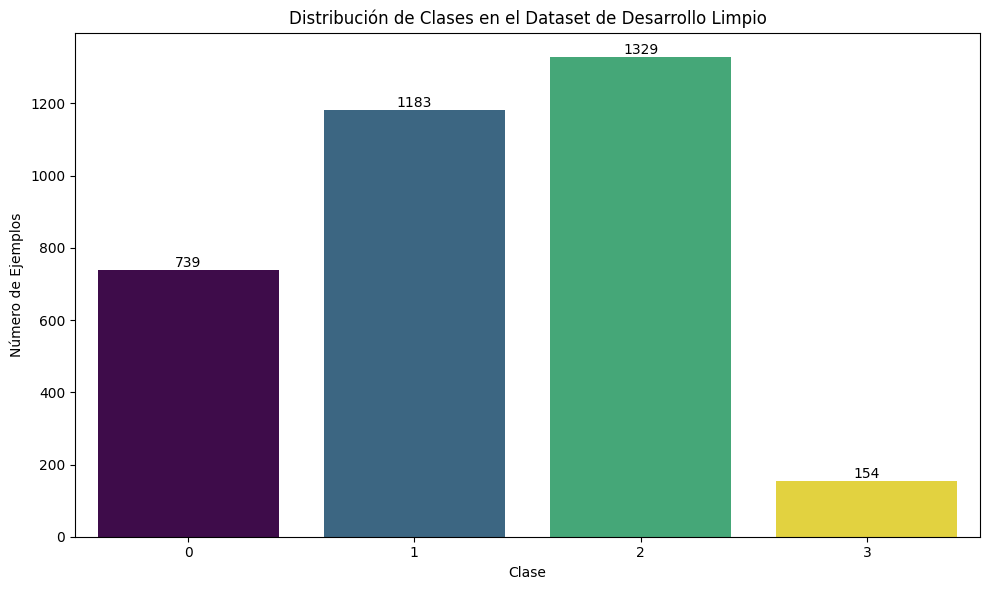

In [ ]:
# Calcular el conteo de cada categoría en la columna 'CLASS' del dataset de desarrollo
class_counts_dev = df_dev['CLASS'].value_counts().sort_index()

print('Balance de categorías en la columna CLASS del dataset de desarrollo:')
print(class_counts_dev)

# Visualizar la distribución de las categorías en el dataset de desarrollo
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts_dev.index, y=class_counts_dev.values, palette='viridis', hue=class_counts_dev.index, legend=False)
plt.title('Distribución de Clases en el Dataset de Desarrollo Limpio')
plt.xlabel('Clase')
plt.ylabel('Número de Ejemplos')
plt.xticks(rotation=0)

# Añadir el conteo exacto encima de cada barra
for index, value in enumerate(class_counts_dev.values):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 8. Preprocesamiento de Texto
Vamos a limpiar y normalizar la columna `TEXT` en ambos DataFrames (`df` y `df_dev`). Esto incluye convertir a minúsculas, eliminar caracteres especiales, eliminar números, eliminar stopwords y lematizar el texto.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Descargar recursos necesarios de NLTK (solo la primera vez)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('spanish')) # Usamos stopwords en español
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower() # Convertir a minúsculas
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text) # Eliminar caracteres no alfanuméricos (manteniendo tildes y ñ)
    text = re.sub(r'\d+', '', text) # Eliminar números
    words = text.split() # Tokenizar
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words] # Eliminar stopwords y lematizar
    return ' '.join(words)

# Aplicar la función de limpieza a ambos DataFrames
print('Aplicando limpieza de texto al DataFrame de entrenamiento...')
df['TEXT_CLEANED'] = df['TEXT'].apply(clean_text)
print('Limpieza de texto completada para el DataFrame de entrenamiento.')

print('\nAplicando limpieza de texto al DataFrame de desarrollo...')
df_dev['TEXT_CLEANED'] = df_dev['TEXT'].apply(clean_text)
print('Limpieza de texto completada para el DataFrame de desarrollo.')

print('\nPrimeras 5 filas del DataFrame de entrenamiento con texto limpio:')
display(df[['TEXT', 'TEXT_CLEANED']].head())

print('\nPrimeras 5 filas del DataFrame de desarrollo con texto limpio:')
display(df_dev[['TEXT', 'TEXT_CLEANED']].head())

Aplicando limpieza de texto al DataFrame de entrenamiento...
Limpieza de texto completada para el DataFrame de entrenamiento.

Aplicando limpieza de texto al DataFrame de desarrollo...
Limpieza de texto completada para el DataFrame de desarrollo.

Primeras 5 filas del DataFrame de entrenamiento con texto limpio:


,TEXT,TEXT_CLEANED
0,MENCIONA QUE REALIZO EL TRAMITE DE DIVORCIO Y ...,menciona realizo tramite divorcio juez familai...
1,"LA USUARIA ESPOSA DEL AGRESOR, DICE QUE LLEVAN...",usuaria esposa agresor dice llevan años casado...
2,USUARIA MENCIONA QUE LLEGO SU EX PAREJA A VER ...,usuaria menciona llego ex pareja ver hija comú...
3,USUARIA ACUDE PARA TRAMITE DE ALIMENTOS.,usuaria acude tramite alimentos
4,LA USUARIA EXPAREJA DEL AGRESOR CON UNA HIJA E...,usuaria expareja agresor hija comun dice otorg...



Primeras 5 filas del DataFrame de desarrollo con texto limpio:


,TEXT,TEXT_CLEANED
0,USUARIA REFIERE QUE AGRESOR ES SU EX PAREJA Y ...,usuaria refiere agresor ex pareja menciona viv...
1,USUARIA MANIFIESTA QUE ACUDE TODA VEZ QUE SU E...,usuaria manifiesta acude toda vez esposo domic...
2,USUARIA MENCIONA QUE ELLA QUIERE REALIZAR TRAM...,usuaria menciona quiere realizar tramite divor...
3,USUARIA MENCIONA QUE TIENE TRES MESES SEPARADA...,usuaria menciona tres meses separada ex pareja...
4,USUARIA REFIERE QUE SU HIJA ES USUARIA DE LA I...,usuaria refiere hija usuaria institucion prese...


### 9. Revisión de la Longitud de los Textos Limpios
Es útil analizar la longitud de los textos después del preprocesamiento para entender la distribución y detectar posibles anomalías o la necesidad de un filtrado adicional.

In [ ]:
# Calcular la longitud de los textos limpios en el DataFrame de entrenamiento
df['TEXT_CLEANED_LENGTH'] = df['TEXT_CLEANED'].apply(len)

# Calcular la longitud de los textos limpios en el DataFrame de desarrollo
df_dev['TEXT_CLEANED_LENGTH'] = df_dev['TEXT_CLEANED'].apply(len)

print('Estadísticas de longitud de TEXT_CLEANED (Entrenamiento):')
display(df['TEXT_CLEANED_LENGTH'].describe())

print('\nEstadísticas de longitud de TEXT_CLEANED (Desarrollo):')
display(df_dev['TEXT_CLEANED_LENGTH'].describe())

Estadísticas de longitud de TEXT_CLEANED (Entrenamiento):


,TEXT_CLEANED_LENGTH
count,13503.000000
mean,348.989632
std,204.619996
min,0.000000
25%,208.000000
50%,311.000000
75%,439.000000
max,1334.000000



Estadísticas de longitud de TEXT_CLEANED (Desarrollo):


,TEXT_CLEANED_LENGTH
count,3405.000000
mean,399.890749
std,252.097762
min,5.000000
25%,232.000000
50%,362.000000
75%,538.000000
max,1376.000000


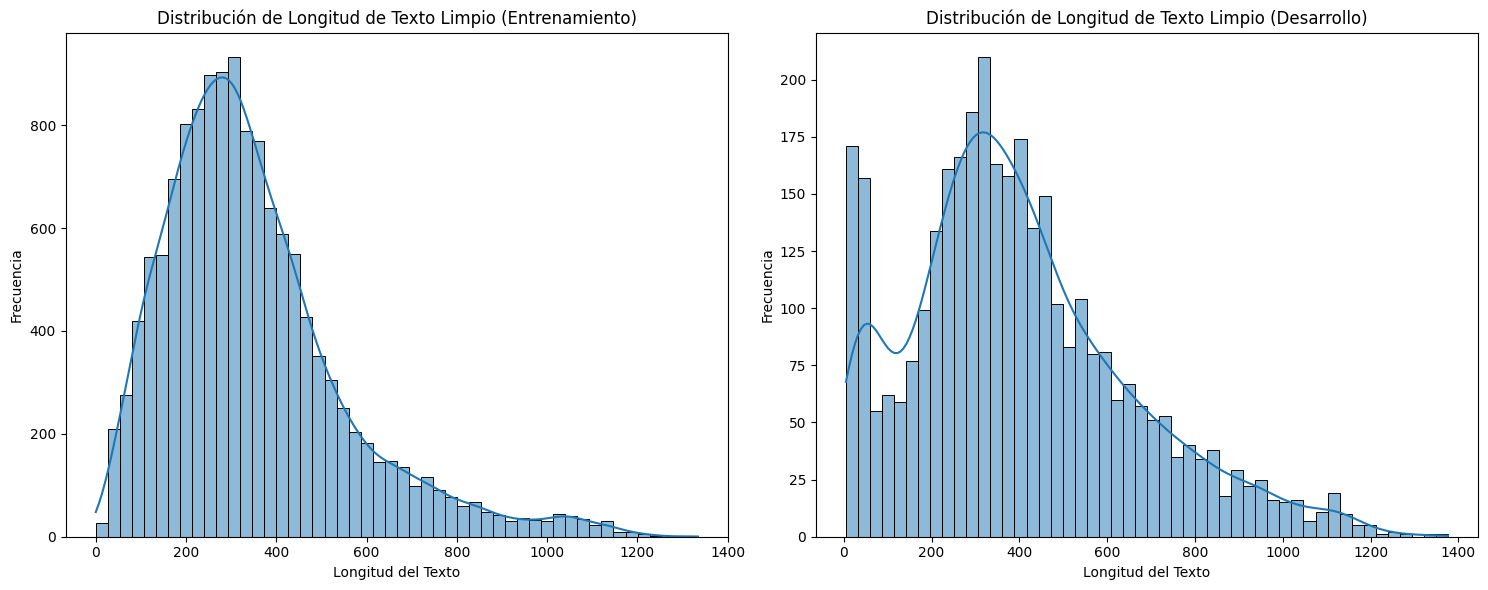

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['TEXT_CLEANED_LENGTH'], bins=50, kde=True)
plt.title('Distribución de Longitud de Texto Limpio (Entrenamiento)')
plt.xlabel('Longitud del Texto')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df_dev['TEXT_CLEANED_LENGTH'], bins=50, kde=True)
plt.title('Distribución de Longitud de Texto Limpio (Desarrollo)')
plt.xlabel('Longitud del Texto')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 10. Vectorización TF-IDF

Ahora convertiremos el texto limpio de ambos conjuntos de datos (entrenamiento y desarrollo) en representaciones numéricas utilizando TF-IDF (Term Frequency-Inverse Document Frequency). Este paso es fundamental para que los algoritmos de aprendizaje automático puedan procesar el texto. Posteriormente, en la etapa de entrenamiento del modelo, abordaremos el desbalance de clases mediante el ajuste de pesos.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print('Aplicando vectorización TF-IDF...')

X_train = df['TEXT_CLEANED']
y_train = df['CLASS']
X_dev = df_dev['TEXT_CLEANED']
y_dev = df_dev['CLASS']

# Inicializar el vectorizador TF-IDF
# max_features: limita el número de características (palabras) a considerar
# min_df: ignora palabras que aparecen en menos del 5% de los documentos
# max_df: ignora palabras que aparecen en más del 80% de los documentos
# ngram_range: considera unigramas y bigramas
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000, # Considerar las 5000 palabras más relevantes
    min_df=5, # Ignorar palabras que aparecen en menos de 5 documentos
    max_df=0.8,
    ngram_range=(1, 2) # Incluir unigramas y bigramas
)

# Ajustar y transformar el conjunto de entrenamiento
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
print(f'Forma de X_train_tfidf: {X_train_tfidf.shape}')

# Transformar el conjunto de desarrollo (solo transformar, no ajustar)
X_dev_tfidf = tfidf_vectorizer.transform(X_dev)
print(f'Forma de X_dev_tfidf: {X_dev_tfidf.shape}')

print('\nVectorización TF-IDF completada.')

Aplicando vectorización TF-IDF...
Forma de X_train_tfidf: (13503, 5000)
Forma de X_dev_tfidf: (3405, 5000)

Vectorización TF-IDF completada.


### 11. Entrenamiento del Modelo de Clasificación (Regresión Logística)

Vamos a entrenar un modelo de Regresión Logística, ya que es un buen punto de partida para datos TF-IDF y permite ajustar los pesos de las clases para abordar el desbalance. Evaluaremos el modelo utilizando el `macro F1-score`, como se solicitó.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

print('Entrenando el modelo de Regresión Logística...')

# Inicializar el modelo de Regresión Logística
# 'class_weight="balanced"' ajusta automáticamente los pesos inversamente proporcionales a las frecuencias de clase.
# 'solver="liblinear"' es bueno para datasets pequeños y para regularización L1/L2.
# 'max_iter' se incrementa para asegurar la convergencia.
log_reg_model = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear', max_iter=200)

# Entrenar el modelo con los datos de entrenamiento TF-IDF
log_reg_model.fit(X_train_tfidf, y_train)

print('Entrenamiento del modelo completado.')

# Realizar predicciones en el conjunto de desarrollo
y_pred = log_reg_model.predict(X_dev_tfidf)

# Evaluar el modelo
print('\nReporte de Clasificación en el conjunto de desarrollo:')
print(classification_report(y_dev, y_pred))

# Calcular el macro F1-score
macro_f1 = f1_score(y_dev, y_pred, average='macro')
print(f'Macro F1-score en el conjunto de desarrollo: {macro_f1:.4f}')

Entrenando el modelo de Regresión Logística...
Entrenamiento del modelo completado.

Reporte de Clasificación en el conjunto de desarrollo:
              precision    recall  f1-score   support

           0       0.56      0.54      0.55       739
           1       0.47      0.51      0.49      1183
           2       0.64      0.61      0.62      1329
           3       0.29      0.25      0.27       154

    accuracy                           0.54      3405
   macro avg       0.49      0.48      0.48      3405
weighted avg       0.55      0.54      0.54      3405

Macro F1-score en el conjunto de desarrollo: 0.4821


### 12. Optimización del Modelo de Regresión Logística con Pesos de Clase Personalizados

Vamos a refinar el modelo de Regresión Logística utilizando pesos de clase personalizados. Esto nos permitirá darle una mayor importancia a las clases minoritarias, como la Clase 3, durante el entrenamiento, con el objetivo de mejorar el `macro F1-score`.

In [ ]:
from sklearn.utils import class_weight
import numpy as np

print('Calculando pesos de clase personalizados...')

# Obtener los conteos de cada clase en el conjunto de entrenamiento original
# Usamos 'class_counts' que ya se calculó para el df (antes del undersampling si se hubiera aplicado)
class_counts_train = df['CLASS'].value_counts().sort_index()

# Obtener la frecuencia de la clase más frecuente para la escala inicial
max_freq = class_counts_train.max()

# Calcular pesos inversamente proporcionales a la frecuencia, escalados para que la clase más frecuente tenga peso 1
custom_class_weights = {
    class_label: max_freq / count
    for class_label, count in class_counts_train.items()
}

# Identificar la clase minoritaria y asignarle un peso de 10
minority_class_label = class_counts_train.idxmin()
custom_class_weights[minority_class_label] = 10.0

print('\nPesos de clase personalizados calculados:')
for label, weight in custom_class_weights.items():
    print(f'  Clase {label}: {weight:.2f}')

print('\nReentrenando el modelo de Regresión Logística con pesos personalizados...')

# Inicializar el modelo de Regresión Logística con los pesos personalizados
log_reg_model_custom_weights = LogisticRegression(
    random_state=42,
    class_weight=custom_class_weights, # Usamos los pesos personalizados aquí
    solver='liblinear',
    max_iter=200
)

# Entrenar el modelo con los datos de entrenamiento TF-IDF
log_reg_model_custom_weights.fit(X_train_tfidf, y_train)

print('Reentrenamiento del modelo con pesos personalizados completado.')

# Realizar predicciones en el conjunto de desarrollo
y_pred_custom_weights = log_reg_model_custom_weights.predict(X_dev_tfidf)

# Evaluar el modelo
print('\nReporte de Clasificación con Pesos Personalizados en el conjunto de desarrollo:')
print(classification_report(y_dev, y_pred_custom_weights))

# Calcular el macro F1-score
macro_f1_custom_weights = f1_score(y_dev, y_pred_custom_weights, average='macro')
print(f'Macro F1-score con Pesos Personalizados en el conjunto de desarrollo: {macro_f1_custom_weights:.4f}')

Calculando pesos de clase personalizados...

Pesos de clase personalizados calculados:
  Clase 0: 1.87
  Clase 1: 1.12
  Clase 2: 1.00
  Clase 3: 10.00

Reentrenando el modelo de Regresión Logística con pesos personalizados...
Reentrenamiento del modelo con pesos personalizados completado.

Reporte de Clasificación con Pesos Personalizados en el conjunto de desarrollo:
              precision    recall  f1-score   support

           0       0.56      0.54      0.55       739
           1       0.47      0.51      0.49      1183
           2       0.64      0.61      0.62      1329
           3       0.30      0.26      0.28       154

    accuracy                           0.55      3405
   macro avg       0.49      0.48      0.49      3405
weighted avg       0.55      0.55      0.55      3405

Macro F1-score con Pesos Personalizados en el conjunto de desarrollo: 0.4861


In [ ]:
import pandas as pd

# Crear un DataFrame con las predicciones
predictions_df = pd.DataFrame(y_pred_custom_weights, columns=['CLASS'])

# Guardar el DataFrame en un archivo CSV sin el encabezado
output_file_path = '/content/drive/MyDrive/PLN/subtask1/subtask1.csv'
predictions_df.to_csv(output_file_path, index=False, header=False)

print(f'Las clasificaciones han sido guardadas exitosamente en: {output_file_path} (sin encabezado).')
print('\nPrimeras 5 filas del archivo CSV generado:')
# Leer de nuevo el archivo para mostrar cómo se ve sin encabezado
display(pd.read_csv(output_file_path, header=None).head())

Las clasificaciones han sido guardadas exitosamente en: /content/drive/MyDrive/PLN/subtask1/subtask1.csv (sin encabezado).

Primeras 5 filas del archivo CSV generado:


,0
0,0
1,0
2,0
3,0
4,1


In [ ]:
import zipfile
import os

# Define the path to the CSV file and the desired zip file name
csv_file_path = '/content/drive/MyDrive/PLN/subtask1/subtask1.csv'
zip_file_name = '/content/drive/MyDrive/PLN/subtask1/predictions.zip' # Changed path here

# Create a ZipFile object in write mode
with zipfile.ZipFile(zip_file_name, 'w') as zf:
    # Add the CSV file to the zip archive
    # The second argument is the name of the file inside the zip archive
    zf.write(csv_file_path, os.path.basename(csv_file_path))

print(f'Archivo {os.path.basename(csv_file_path)} comprimido en {zip_file_name} exitosamente.')

Archivo subtask1.csv comprimido en /content/drive/MyDrive/PLN/subtask1/predictions.zip exitosamente.


### 13. Predicción con el Modelo Entrenado en el Dataset de Test

Ahora, utilizaremos el modelo de Regresión Logística entrenado con pesos personalizados para hacer predicciones en el dataset de test. Seguiremos los mismos pasos de preprocesamiento y vectorización aplicados a los datasets de entrenamiento y desarrollo.

In [ ]:
# Cargar el dataset de test
file_path_test = '/content/drive/MyDrive/PLN/subtask1/test.csv'

try:
    # Cargar el CSV y asignar el nombre 'TEXT' a la única columna.
    # Asumimos que el dataset de test no tiene encabezado, por lo que usamos 'header=None'
    # y luego renombramos la columna 0 a 'TEXT'.
    df_test = pd.read_csv(file_path_test, header=None)
    df_test.rename(columns={0: 'TEXT'}, inplace=True)
    print(f'Dataset de test cargado exitosamente desde: {file_path_test}')

    print('\nPrimeras 5 filas del dataset de test:')
    display(df_test.head())

    print('\nNombres de las columnas del dataset de test:')
    for col_test in df_test.columns:
        print(f'- {col_test}')

    print('\nInformación del DataFrame de test:')
    df_test.info()

except FileNotFoundError:
    print(f'Error: El archivo de test no fue encontrado en la ruta: {file_path_test}')
    print('Por favor, verifica que la ruta sea correcta y que el archivo exista en tu Google Drive.')
except Exception as e:
    print(f'Ocurrió un error al cargar el dataset de test: {e}')

Dataset de test cargado exitosamente desde: /content/drive/MyDrive/PLN/subtask1/test.csv

Primeras 5 filas del dataset de test:


,TEXT
0,REFIERE USUARIA QUE EL DIA DE AYER JUEVES DE F...
1,LA USUARIA MANIFIESTA QUE EL SEÑOR LLEGA AL DO...
2,US. REFIERE QUE HACE UN MES APROX. LE MARCO PO...
3,USURIA ACUDE A TRAMITE DE PENSION ALIMENTICIA
4,"LLEGO EL AGRESOR SE METE AL PATIO DE ATRAS, LE..."



Nombres de las columnas del dataset de test:
- TEXT

Información del DataFrame de test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4219 entries, 0 to 4218
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   TEXT    4219 non-null   object
dtypes: object(1)
memory usage: 33.1+ KB


In [ ]:
# Aplicar la misma función de limpieza de texto al DataFrame de test
print('Aplicando limpieza de texto al DataFrame de test...')
df_test['TEXT_CLEANED'] = df_test['TEXT'].apply(clean_text)
print('Limpieza de texto completada para el DataFrame de test.')

print('\nPrimeras 5 filas del DataFrame de test con texto limpio:')
display(df_test[['TEXT', 'TEXT_CLEANED']].head())

Aplicando limpieza de texto al DataFrame de test...
Limpieza de texto completada para el DataFrame de test.

Primeras 5 filas del DataFrame de test con texto limpio:


,TEXT,TEXT_CLEANED
0,REFIERE USUARIA QUE EL DIA DE AYER JUEVES DE F...,refiere usuaria dia ayer jueves febrero noche ...
1,LA USUARIA MANIFIESTA QUE EL SEÑOR LLEGA AL DO...,usuaria manifiesta señor llega domicilio acude...
2,US. REFIERE QUE HACE UN MES APROX. LE MARCO PO...,u refiere hace me aprox marco telefono reclama...
3,USURIA ACUDE A TRAMITE DE PENSION ALIMENTICIA,usuria acude tramite pension alimenticia
4,"LLEGO EL AGRESOR SE METE AL PATIO DE ATRAS, LE...",llego agresor mete patio atras dijo hijo merie...


In [ ]:
# Transformar el texto limpio del dataset de test utilizando el vectorizador TF-IDF ya ajustado
print('Transformando el texto del dataset de test con TF-IDF...')
X_test_tfidf = tfidf_vectorizer.transform(df_test['TEXT_CLEANED'])
print(f'Forma de X_test_tfidf: {X_test_tfidf.shape}')
print('Transformación TF-IDF para el dataset de test completada.')

Transformando el texto del dataset de test con TF-IDF...
Forma de X_test_tfidf: (4219, 5000)
Transformación TF-IDF para el dataset de test completada.


In [ ]:
# Realizar predicciones en el conjunto de test con el modelo reentrenado con pesos personalizados
print('Realizando predicciones en el dataset de test...')
y_pred_test = log_reg_model_custom_weights.predict(X_test_tfidf)
print('Predicciones completadas.')

# Mostrar las primeras 5 predicciones
print('\nPrimeras 5 predicciones en el dataset de test:')
print(y_pred_test[:5])

Realizando predicciones en el dataset de test...
Predicciones completadas.

Primeras 5 predicciones en el dataset de test:
[2 2 1 0 2]


In [ ]:
# Guardar las predicciones en un archivo CSV sin encabezado, siguiendo el formato de subtask1.csv
predictions_test_df = pd.DataFrame(y_pred_test, columns=['CLASS'])

output_test_file_path = '/content/drive/MyDrive/PLN/subtask1/test_predictions.csv'
predictions_test_df.to_csv(output_test_file_path, index=False, header=False)

print(f'Las predicciones para el dataset de test han sido guardadas exitosamente en: {output_test_file_path} (sin encabezado).')
print('\nPrimeras 5 filas del archivo CSV de predicciones de test generado:')
display(pd.read_csv(output_test_file_path, header=None).head())

Las predicciones para el dataset de test han sido guardadas exitosamente en: /content/drive/MyDrive/PLN/subtask1/test_predictions.csv (sin encabezado).

Primeras 5 filas del archivo CSV de predicciones de test generado:


,0
0,2
1,2
2,1
3,0
4,2


In [ ]:
# Comprimir el archivo de predicciones de test
import zipfile
import os

csv_test_file_path = '/content/drive/MyDrive/PLN/subtask1/test_predictions.csv'
zip_test_file_name = '/content/drive/MyDrive/PLN/subtask1/test_predictions.zip'

with zipfile.ZipFile(zip_test_file_name, 'w') as zf:
    zf.write(csv_test_file_path, 'subtask1.csv') # Cambiado el nombre interno del archivo en el zip

print(f'Archivo {os.path.basename(csv_test_file_path)} comprimido en {zip_test_file_name} exitosamente con el nombre interno subtask1.csv.')

Archivo test_predictions.csv comprimido en /content/drive/MyDrive/PLN/subtask1/test_predictions.zip exitosamente con el nombre interno subtask1.csv.
